<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P3/TUGAS_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

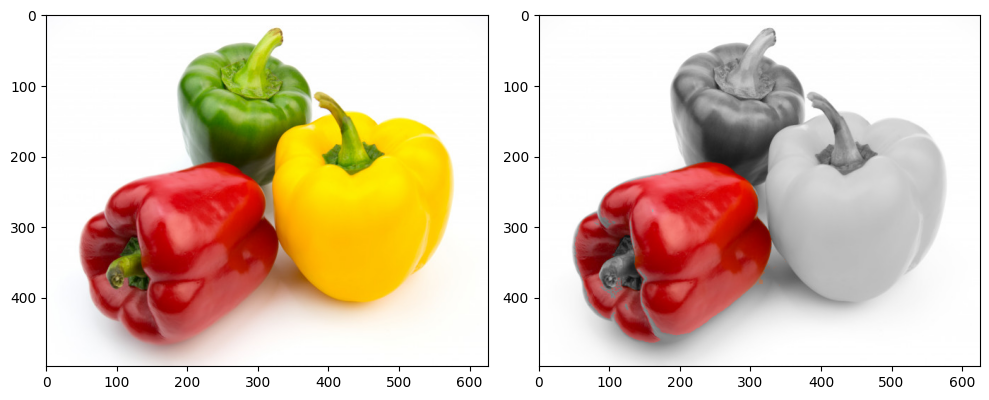

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img_path = '/content/drive/MyDrive/PCVK_2026/peppers.jpg'
img = cv.imread(img_path)

if img is None:
    print(f"Error: File tidak ditemukan di {img_path}")
else:

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)
    mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)
    red_mask = cv.bitwise_or(mask1, mask2)

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

    result = np.where(red_mask[:, :, None] == 255, img_rgb, gray_3ch)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)

    plt.subplot(1, 2, 2)
    plt.imshow(result)

    plt.tight_layout()
    plt.show()